In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("nyc-jobs") \
    .master("local[*]") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/25 12:31:50 WARN Utils: Your hostname, Pranavs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.4 instead (on interface en0)
26/02/25 12:31:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/25 12:31:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [3]:
"""
NYC jobs dataset analysis using PySpark.

1. exploration
2.  salary normalization
3.few extra features
4.KPI calculations
5. writing processed output
"""

'\nNYC jobs dataset analysis using PySpark.\n\n1. exploration\n2.  salary normalization\n3.few extra features\n4.KPI calculations\n5. writing processed output\n'

### Read data

In [4]:
df = spark.read.csv("../../dataset/nyc-jobs.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5, truncate=False)

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

26/02/25 12:31:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


### Sample function

In [5]:
def get_salary_frequency(df: DataFrame) -> list:
    row_list = df.select('Salary Frequency').distinct().collect()
    return [row['Salary Frequency'] for row in row_list]

### Example of test function

In [6]:
mock_data = [('A', 'Annual'), ('B', 'Daily')]
expected_result = ['Annual', 'Daily']

In [7]:
def test_get_salary_frequency(mock_data: list, 
                              expected_result: list,
                              schema: list = ['id', 'Salary Frequency']):  
    mock_df = spark.createDataFrame(data = mock_data, schema = schema)
    assert get_salary_frequency(mock_df) == expected_result

In [8]:
#exploring data

In [9]:
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
print("Columns:", df.columns)

Total Rows: 2946
Total Columns: 28
Columns: ['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Salary Range From', 'Salary Range To', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement', 'Posting Date', 'Post Until', 'Posting Updated', 'Process Date']


In [10]:
from pyspark.sql.functions import col, sum as _sum
null_counts = df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

+------+------+------------+--------------+--------------+-------------------+-------------+-----+------------+-----------------------------+-----------------+---------------+----------------+-------------+------------------+---------------+-------------------------+----------------+----------------------+--------+-----------+---------------+-------------------+---------------------+------------+----------+---------------+------------+
|Job ID|Agency|Posting Type|# Of Positions|Business Title|Civil Service Title|Title Code No|Level|Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|Work Location|Division/Work Unit|Job Description|Minimum Qual Requirements|Preferred Skills|Additional Information|To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Date|Post Until|Posting Updated|Process Date|
+------+------+------------+--------------+--------------+-------------------+-------------+-----+------------+---------

In [11]:
df.select("Salary Frequency").distinct().show()
df.select("Salary Range From", "Salary Range To").show(5, truncate=False)

+----------------+
|Salary Frequency|
+----------------+
|          Annual|
|           Daily|
|          Hourly|
+----------------+

+-----------------+---------------+
|Salary Range From|Salary Range To|
+-----------------+---------------+
|42405.0          |65485.0        |
|60740.0          |162014.0       |
|51907.68         |54580.32       |
|51907.68         |54580.32       |
|35.0             |35.0           |
+-----------------+---------------+
only showing top 5 rows


In [12]:
#Data Cleaning and   Transformation

In [13]:
from pyspark.sql.functions import col, when
def normalize_salary(df):

    df = df.withColumn(
        "salary_midpoint",
        (col("Salary Range From").cast("double") +
         col("Salary Range To").cast("double")) / 2
    )
    freq = col("Salary Frequency")
    df = df.withColumn(
        "annual_salary",
        when(freq == "Annual", col("salary_midpoint"))
        .when(freq == "Daily", col("salary_midpoint") * 260)
        .when(freq == "Hourly", col("salary_midpoint") * 2080)
        .otherwise(None)
    )
    return df

In [14]:
df_clean = normalize_salary(df)

In [15]:
from pyspark.sql.functions import to_timestamp, coalesce
def parse_posting_date(df):
    return df.withColumn(
        "posting_date",
        coalesce(to_timestamp(col("Posting Date"), "MM/dd/yyyy"),to_timestamp(col("Posting Date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"))
    )

In [16]:
df_clean = parse_posting_date(df_clean)

In [17]:
#creating additional fEatures

In [18]:
from pyspark.sql.functions import coalesce, lit, lower

def extract_degree_level(df):

    df = df.withColumn("min_req",lower(coalesce(col("Minimum Qual Requirements"), lit(""))))
    df = df.withColumn("degree_level",when(col("min_req").rlike("phd"), 4).when(col("min_req").rlike("master"), 3).
        when(col("min_req").rlike("bachelor"), 2).when(col("min_req").rlike("high school"), 1).otherwise(0))
    return df.drop("min_req")

In [19]:
df_clean = extract_degree_level(df_clean)

In [20]:
from pyspark.sql.functions import size, split
def skill_count_feature(df):
    return df.withColumn("skill_count",size(split(coalesce(col("Preferred Skills"), lit("")), ",")))

In [21]:
df_clean = extract_degree_level(df_clean)

In [22]:
corr = df_clean.select("degree_level", "annual_salary") \
    .na.drop() \
    .stat.corr("degree_level", "annual_salary")
print("Degree vs Salary correlation:", corr)

Degree vs Salary correlation: 0.12123388393811257


In [23]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
def highest_salary_per_agency(df):
    w = Window.partitionBy("Agency") \
              .orderBy(col("annual_salary").desc())
    df_ranked = df.withColumn("rnk", row_number().over(w))
    return df_ranked.filter(col("rnk") == 1).drop("rnk")
highest_salary_per_agency(df_clean).show()

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+-----------------+------------------+-------------------+------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|         H

In [24]:
#DROPPING COLUMNS
cols_to_drop = ["Recruitment Contact","Additional Information","To Apply","Hours/Shift"]
df_clean = df_clean.drop(*cols_to_drop)
print("Remaining Columns:", len(df_clean.columns))

Remaining Columns: 28


In [25]:
# KPI

In [26]:
def top_10_job_categories(df):
    return (df.groupBy("Job Category").count().orderBy(col("count").desc()).limit(10))
top_10_job_categories(df_clean).show()

+--------------------+-----+
|        Job Category|count|
+--------------------+-----+
|Engineering, Arch...|  504|
|Technology, Data ...|  313|
|       Legal Affairs|  226|
|Public Safety, In...|  182|
|Building Operatio...|  181|
|Finance, Accounti...|  169|
|Administration & ...|  134|
|Constituent Servi...|  129|
|              Health|  125|
|Policy, Research ...|  124|
+--------------------+-----+



In [27]:
from pyspark.sql.functions import avg

def salary_distribution_by_category(df):

    df_valid = df.filter(col("annual_salary").isNotNull())

    return (
        df_valid.groupBy("Job Category").agg(avg("annual_salary").alias("avg_salary")).orderBy(col("avg_salary").desc())
    )

In [28]:
from pyspark.sql.functions import current_date, datediff
def avg_salary_last_2_years(df):
    df_recent = df.filter((col("posting_date").isNotNull()) & (datediff(current_date(), col("posting_date")) <= 730))
    return (df_recent.groupBy("Agency").agg({"annual_salary": "avg"}).withColumnRenamed("avg(annual_salary)", "avg_salary"))
avg_salary_last_2_years(df_clean).show()

+------+----------+
|Agency|avg_salary|
+------+----------+
+------+----------+



In [29]:
from pyspark.sql.functions import (
    explode, split, trim, lower, length,
    col, regexp_replace)
def highest_paid_skills(df):
#Ensuring Preferred Skills is not null
    df = df.filter(col("Preferred Skills").isNotNull())
#splittin preferred skills and compute average salary per skill
    df_skills = df.withColumn(
        "skill_raw",explode(split(regexp_replace(col("Preferred Skills"), "\n", ","),",")))
    df_skills = df_skills.withColumn(
        "skill",lower(trim(col("skill_raw")))  )
    df_skills = df_skills.filter((col("skill").isNotNull()) &(length(col("skill")) > 4) &
        (~col("skill").contains("experience")) &(~col("skill").contains("ability")) &(col("annual_salary").isNotNull()))
    return (df_skills.groupBy("skill").avg("annual_salary").withColumnRenamed("avg(annual_salary)", "avg_salary").orderBy(col("avg_salary").desc())
    )

In [30]:
df_clean.write.mode("overwrite").parquet("output/nyc_jobs_processed")

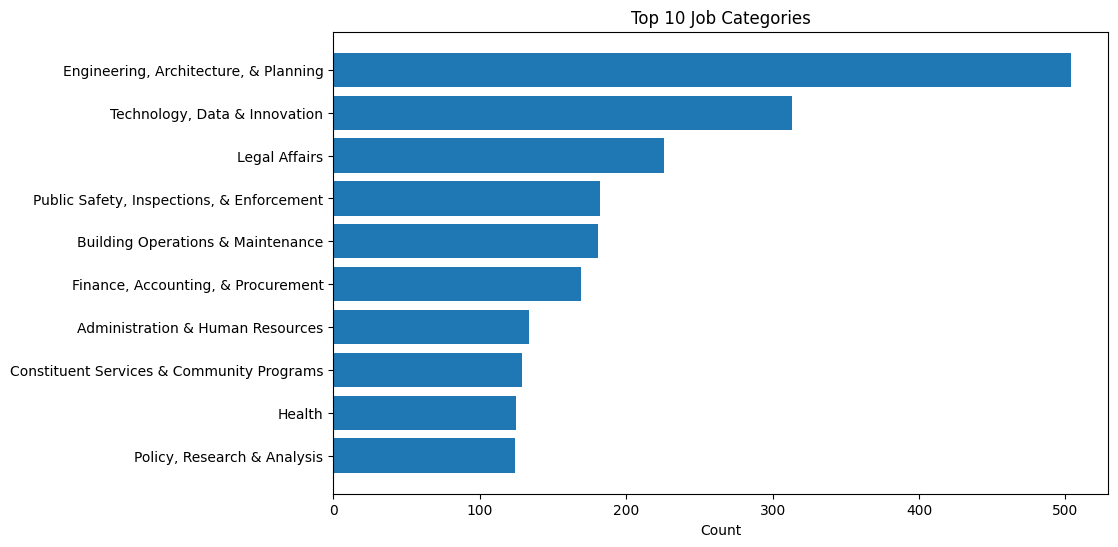

In [31]:
import matplotlib.pyplot as plt
top10_pd = top_10_job_categories(df_clean).toPandas()

plt.figure(figsize=(10,6))
plt.barh(top10_pd["Job Category"], top10_pd["count"])
plt.xlabel("Count")
plt.title("Top 10 Job Categories")
plt.gca().invert_yaxis()
plt.show()